# 42173 Advanced Natural Language Processing
## Component: Retrieval Evaluator — PubMedQA + T5


## 1. Setup

In [1]:
!pip -q install datasets transformers torch pandas matplotlib

In [2]:
# Import libraries
import os
import json
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import T5Tokenizer, T5EncoderModel

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Set model name 
MODEL_NAME = "t5-small"  

# Set device to GPU if available, otherwise CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

/opt/anaconda3/envs/fundamentals_of_da/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 2. Load the PubMedQA dataset

Uses the **PQA-Labeled (PQA-L)** split — 1,000 expert-annotated samples.


In [3]:
from datasets import load_dataset

pubmedqa = None
pubmedqa_labeled = "pqa_labeled"
pubmedqa_artificial = "pqa_artificial"

for name in ["qiaojin/PubMedQA", "pubmed_qa"]:
    try:
        pubmedqa = load_dataset(name, pubmedqa_labeled, split="train")
        print(f"Loaded from: {name}")
        break
    except Exception as e:
        print(f"Could not load {name}: {e}")

assert pubmedqa is not None, "Could not load PubMedQA. Check the dataset name on huggingface.co/datasets"


Loaded from: qiaojin/PubMedQA


In [4]:
def join_context(example):
    """
    Example['context']['contexts'] is a list of abstract sections -- join into one string.
    """
    ctx = example["context"]
    if isinstance(ctx, dict) and "contexts" in ctx:
        return " ".join(ctx["contexts"])
    return str(ctx)

records = []
for record in pubmedqa:
    records.append({
        "question": record["question"],
        "context": join_context(record),
        "final_decision": record.get("final_decision", None),
    })

pubmedqa_df = pd.DataFrame(records)
print(f"Total samples: {len(pubmedqa_df)}")
pubmedqa_df.head(3)


Total samples: 1000


,question,context,final_decision
0,Do mitochondria play a role in remodelling lac...,Programmed cell death (PCD) is the regulated d...,yes
1,Landolt C and snellen e acuity: differences in...,Assessment of visual acuity depends on the opt...,no
2,"Syncope during bathing in infants, a pediatric...",Apparent life-threatening events in infants ar...,yes


## 3. Visualize the data

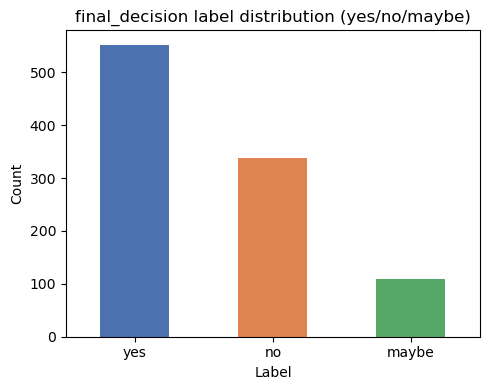

In [5]:
# Label distribution (yes/no/maybe)
fig, ax = plt.subplots(figsize=(5, 4))
pubmedqa_df["final_decision"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("final_decision label distribution (yes/no/maybe)")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

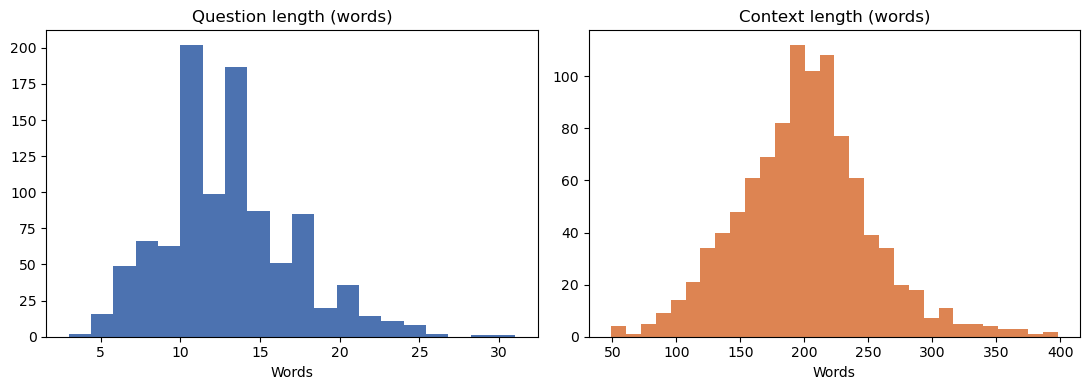

       question_len  context_len
count   1000.000000  1000.000000
mean      12.913000   200.207000
std        4.100518    51.846429
min        3.000000    49.000000
25%       10.000000   166.750000
50%       13.000000   200.500000
75%       15.000000   228.000000
max       31.000000   398.000000


In [6]:
# Question and context length (word count)
pubmedqa_df["question_len"] = pubmedqa_df["question"].str.split().str.len()
pubmedqa_df["context_len"] = pubmedqa_df["context"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(pubmedqa_df["question_len"], bins=20, color="#4C72B0")
axes[0].set_title("Question length (words)")
axes[0].set_xlabel("Words")

axes[1].hist(pubmedqa_df["context_len"], bins=30, color="#DD8452")
axes[1].set_title("Context length (words)")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

print(pubmedqa_df[["question_len", "context_len"]].describe())

In [7]:
# Look at real examples
for i in range(3):
    row = pubmedqa_df.iloc[i]
    print(f"--- Example {i+1} ---")
    print("Question:", row["question"])
    print("Context :", row["context"][:300], "...")
    print("Label   :", row["final_decision"])
    print()

--- Example 1 ---
Question: Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
Context : Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cel ...
Label   : yes

--- Example 2 ---
Question: Landolt C and snellen e acuity: differences in strabismus amblyopia?
Context : Assessment of visual acuity depends on the optotypes used for measurement. The ability to recognize different optotypes differs even if their critical details appear under the same visual angle. Since optotypes are evaluated on individuals with good visual acuity and without eye disorders, differenc ...
Label   : no

--- Example 3 ---
Question: Syncope during bathing in infants, a pediatric form of water-induced urticaria?
Context : Apparen

## 4. Build training pairs (question, document, label)

- **Positive (+1):** question A + the real context of A (already in the data).
- **Negative (-1):** question A + a random context from a different question (unrelated to A).

Split the data into train / validation / test before building pairs, so the test set never leaks into training.


In [24]:
N_TRAIN = 950
N_VAL = 45
N_TEST = 5

shuffled = pubmedqa_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
train_df = shuffled.iloc[:N_TRAIN].reset_index(drop=True)
val_df = shuffled.iloc[N_TRAIN:N_TRAIN + N_VAL].reset_index(drop=True)
test_df = shuffled.iloc[N_TRAIN + N_VAL:N_TRAIN + N_VAL + N_TEST].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 950 | Val: 45 | Test: 5


In [9]:
def build_training_pairs(df, all_contexts, n_negatives_per_question=2):
    """
    1 positive (real context) + n negative (random context) per question.
    """
    pairs = []
    for _, row in df.iterrows():
        question = row["question"]
        gold_context = row["context"]

        pairs.append({"question": question, "document": gold_context, "label": 1.0})

        negatives = random.sample(
            [c for c in all_contexts if c != gold_context],
            min(n_negatives_per_question, len(all_contexts) - 1)
        )
        for neg in negatives:
            pairs.append({"question": question, "document": neg, "label": -1.0})
    return pd.DataFrame(pairs)

all_contexts = pubmedqa_df["context"].tolist()  # pool to draw negatives from
train_pairs_df = build_training_pairs(train_df, all_contexts)
val_pairs_df = build_training_pairs(val_df, all_contexts)

print(f"Training pairs: {len(train_pairs_df)}  "
      f"(positive: {(train_pairs_df.label > 0).sum()}, negative: {(train_pairs_df.label < 0).sum()})")
train_pairs_df.head()


Training pairs: 2850  (positive: 950, negative: 1900)


,question,document,label
0,Pap smears with glandular cell abnormalities: ...,Rapid prescreening (RPS) is one of the quality...,1.0
1,Pap smears with glandular cell abnormalities: ...,to describe variation in utilisation of caroti...,-1.0
2,Pap smears with glandular cell abnormalities: ...,Angiotensin-converting enzyme inhibitors (ACE-...,-1.0
3,Are patients with Werlhof's disease at increas...,"It is generally assumed, that patients with We...",1.0
4,Are patients with Werlhof's disease at increas...,The records of 465 patients with an establishe...,-1.0


## 5. Model definition — T5 encoder + regression head

Same architecture family as the CRAG paper's evaluator: a T5 encoder plus a
linear head, outputting a continuous score in [-1, 1].


In [10]:
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

class T5RelevanceScorer(nn.Module):
    """
    T5 encoder + mean pooling + linear head -> score in [-1, 1].
    """

    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.encoder = T5EncoderModel.from_pretrained(model_name)
        hidden = self.encoder.config.d_model
        self.head = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1e-6)
        return torch.tanh(self.head(pooled)).squeeze(-1)

class RelevanceDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=384):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = f"question: {row['question']} document: {row['document']}"
        enc = self.tokenizer(text, truncation=True, max_length=self.max_length,
                              padding="max_length", return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(row["label"], dtype=torch.float),
        }


## 6. Fine-tune

In [11]:
# Set hyperparameters
EPOCHS = 3
BATCH_SIZE = 8
LR = 2e-5

# Create datasets and dataloaders
train_dataset = RelevanceDataset(train_pairs_df, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = RelevanceDataset(val_pairs_df, tokenizer)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Initialize model, optimizer, and loss function
evaluator_model = T5RelevanceScorer(MODEL_NAME).to(DEVICE)
optimizer = torch.optim.AdamW(evaluator_model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

def run_eval(loader):
    """
    Evaluate the model on a validation set.
    """
    evaluator_model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            pred = evaluator_model(batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE))
            loss = loss_fn(pred, batch["label"].to(DEVICE))
            total_loss += loss.item()
    evaluator_model.train()
    return total_loss / len(loader)

Loading weights: 100%|██████████| 51/51 [00:00<00:00, 11874.63it/s]


In [12]:
CHECKPOINT_PATH = "../models/t5_relevance_evaluator_pubmedqa.pt"

# Load trained model if it exists
if os.path.isfile(CHECKPOINT_PATH):
    print(f"Found trained model: {CHECKPOINT_PATH}")
    evaluator_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
else:
    print("No trained model found — will train from scratch.")
    evaluator_model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            optimizer.zero_grad()
            pred = evaluator_model(batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE))
            loss = loss_fn(pred, batch["label"].to(DEVICE))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        val_loss = run_eval(val_loader)
        print(f"Epoch {epoch+1}: train MSE = {epoch_loss/len(train_loader):.4f} | val MSE = {val_loss:.4f}")

torch.save(evaluator_model.state_dict(), CHECKPOINT_PATH)
print(f"Saved checkpoint: {CHECKPOINT_PATH}")


No trained model found — will train from scratch.


Epoch 1/3: 100%|██████████| 357/357 [08:14<00:00,  1.38s/it]


Epoch 1: train MSE = 0.7183 | val MSE = 0.1843


Epoch 2/3: 100%|██████████| 357/357 [07:15<00:00,  1.22s/it]


Epoch 2: train MSE = 0.1093 | val MSE = 0.1385


Epoch 3/3: 100%|██████████| 357/357 [08:15<00:00,  1.39s/it]


Epoch 3: train MSE = 0.0463 | val MSE = 0.0829
Saved checkpoint: ../models/t5_relevance_evaluator_pubmedqa.pt


## 7. Evaluate relevance function


In [13]:
evaluator_model.eval()

@torch.no_grad()
def evaluate_relevance(question, doc_text):
    """
    Return a relevance score in [-1, 1] for a (question, document) pair.
    """
    text = f"question: {question} document: {doc_text}"
    enc = tokenizer(text, truncation=True, max_length=384, padding="max_length", return_tensors="pt")
    score = evaluator_model(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE))
    return float(score.item())


## 8. Test on 5 questions

For each question in the held-out test set (never used in training), compare
the scores for:
- Its **true context** (expected: high score)
- A **wrong context** (randomly drawn from a different question, expected: low score)


In [27]:
test_results = []
all_contexts = pubmedqa_df["context"].tolist() 

for _, row in test_df.iterrows():
    question = row["question"]
    gold_context = row["context"]
    wrong_context = random.choice([c for c in all_contexts if c != gold_context])

    score_gold = evaluate_relevance(question, gold_context)
    score_wrong = evaluate_relevance(question, wrong_context)

    test_results.append({
        "question": question[:80] + ("..." if len(question) > 80 else ""),
        "score_gold_context": round(score_gold, 3),
        "score_wrong_context": round(score_wrong, 3),
        "correctly_separated": score_gold > score_wrong,
    })

test_results_df = pd.DataFrame(test_results)
test_results_df


,question,score_gold_context,score_wrong_context,correctly_separated
0,"""Would a man smell a rose then throw it away?",-0.933,-0.864,False
1,The effect of an intracerebroventricular injec...,0.926,-0.954,True
2,Is fetal anatomic assessment on follow-up ante...,0.924,-0.959,True
3,Steroids in aminoglycoside-containing ear drop...,0.911,-0.961,True
4,Assessment of appropriate antimicrobial prescr...,0.922,-0.955,True


In [28]:
n_correct = test_results_df["correctly_separated"].sum()
print(f"Correctly separated (true-context score > wrong-context score): {n_correct}/{len(test_results_df)}")


Correctly separated (true-context score > wrong-context score): 4/5


## 9. Test on PQA - Artificial

In [29]:
N_TEST = 100

pubmedqa_a = load_dataset("qiaojin/PubMedQA", pubmedqa_artificial, split="train")

records_a = []
for ex in pubmedqa_a:
    records_a.append({
        "question": ex["question"],
        "context": join_context(ex),
        "final_decision": ex.get("final_decision", None),
    })

pubmedqa_a_df = pd.DataFrame(records_a)
test_df_a = pubmedqa_a_df.sample(n=N_TEST, random_state=42).reset_index(drop=True)
print(f"Test (from PQA-A): {len(test_df_a)}")

Test (from PQA-A): 100


In [30]:
test_results_a = []
all_contexts_a = pubmedqa_a_df["context"].tolist()

for _, row in test_df_a.iterrows():
    question = row["question"]
    gold_context = row["context"]
    wrong_context = random.choice([c for c in all_contexts_a if c != gold_context])

    score_gold = evaluate_relevance(question, gold_context)
    score_wrong = evaluate_relevance(question, wrong_context)

    test_results_a.append({
        "question": question[:80] + ("..." if len(question) > 80 else ""),
        "score_gold_context": round(score_gold, 3),
        "score_wrong_context": round(score_wrong, 3),
        "correctly_separated": score_gold > score_wrong,
    })

test_results_a_df = pd.DataFrame(test_results_a)
test_results_a_df


,question,score_gold_context,score_wrong_context,correctly_separated
0,Do the Norwegian national project for ethics s...,0.911,-0.958,True
1,Is heart-type fatty acid binding protein an ea...,0.919,-0.923,True
2,Does nitric oxide modulate spreading depolariz...,0.917,-0.877,True
3,Do vitamin D receptor alleles predict growth a...,0.921,-0.958,True
4,Does new FIGO staging system of vulvar cancer ...,0.910,-0.954,True
...,...,...,...,...
95,Is there no evidence for an increase in acute ...,0.911,-0.960,True
96,Do effects of activated T cells on osteoclasto...,0.922,-0.954,True
97,Does aP-2β be a Downstream Effector of PITX2 R...,0.924,-0.951,True
98,"Is lipolysis -- not inflammation , cell death ...",0.925,-0.957,True


In [31]:
n_correct = test_results_a_df["correctly_separated"].sum()
print(f"Correctly separated (true-context score > wrong-context score): {n_correct}/{len(test_results_a_df)}")

Correctly separated (true-context score > wrong-context score): 100/100
